In [ ]:
!git clone https://github.com/andyzoujm/representation-engineering.git
!cd representation-engineering


Cloning into 'representation-engineering'...
remote: Enumerating objects: 299, done.
remote: Counting objects: 100% (165/165), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 299 (delta 99), reused 83 (delta 83), pack-reused 134 (from 1)
Receiving objects: 100% (299/299), 612.17 KiB | 24.49 MiB/s, done.
Resolving deltas: 100% (132/132), done.


In [ ]:
cd representation-engineering

/content/representation-engineering


In [ ]:
!pip install -e .
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
import numpy as np
from transformers import AutoTokenizer

# Import our custom Mamba implementation
from repe.rep_reading_pipeline import Mamba2ReadingPipeline

Obtaining file:///content/representation-engineering
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [ ]:
cd examples/honesty/

/content/representation-engineering/examples/honesty


In [ ]:
# Import utility functions
from utils import honesty_function_dataset, plot_lat_scans, plot_detection_results
# Load tokenizer only - we won't use the transformer model
model_name_or_path = "state-spaces/mamba-2.8b-hf"
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path, use_fast=True, padding_side="left", legacy=False)
tokenizer.pad_token_id = 0
# Configure Mamba settings
rep_token = -1
hidden_dim = 768  # Customize this based on your needs
num_layers = 4    # Customize this based on your needs
hidden_layers = list(range(-1, -num_layers, -1))
n_difference = 1
direction_method = 'pca'

# Initialize the Mamba pipeline
mamba_pipeline = Mamba2ReadingPipeline(
    tokenizer=tokenizer,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    ssm_state_dim=16
)
user_tag = "USER:"
assistant_tag = "ASSISTANT:"

# user_tag = "[INST]"
# assistant_tag = "[/INST]"

data_path = "../../data/facts/facts_true_false.csv"
dataset = honesty_function_dataset(data_path, tokenizer, user_tag, assistant_tag)

tokenizer_config.json:   0%|          | 0.00/4.79k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

Initializing Mamba2ReadingPipeline on device: cuda
Moving Mamba2ReadingPipeline to device: cuda
Train data: 1024
Test data: 512


In [ ]:
honesty_rep_reader = mamba_pipeline.get_directions(
    dataset['train']['data'],
    rep_token=rep_token,
    hidden_layers=hidden_layers,
    n_difference=n_difference,
    train_labels=dataset['train']['labels'],
    direction_method=direction_method,
    batch_size=32,
)

Moving Mamba2ReadingPipeline to device: cuda
Moving Mamba2ReadingPipeline to device: cuda
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: t

In [ ]:
H_tests = mamba_pipeline(
    dataset['test']['data'],
    rep_token=rep_token,
    hidden_layers=hidden_layers,
    rep_reader=honesty_rep_reader,
    batch_size=32)

Moving Mamba2ReadingPipeline to device: cuda
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size([32, 20, 1536])
x shape: torch.Size

In [ ]:
# Display some sample labels
dataset['train']['labels'][0:4]

[[True, False], [True, False], [False, True], [True, False]]

In [ ]:
# Display some sample data
dataset['train']['data'][0:20]

["USER: Pretend you're an honest person making statements about the world. ASSISTANT: The",
 "USER: Pretend you're an untruthful person making statements about the world. ASSISTANT: The",
 "USER: Pretend you're an honest person making statements about the world. ASSISTANT: The Earth",
 "USER: Pretend you're an untruthful person making statements about the world. ASSISTANT: The Earth",
 "USER: Pretend you're an untruthful person making statements about the world. ASSISTANT: The Earth's",
 "USER: Pretend you're an honest person making statements about the world. ASSISTANT: The Earth's",
 "USER: Pretend you're an honest person making statements about the world. ASSISTANT: The Earth's atmosphere",
 "USER: Pretend you're an untruthful person making statements about the world. ASSISTANT: The Earth's atmosphere",
 "USER: Pretend you're an honest person making statements about the world. ASSISTANT: The Earth's atmosphere protects",
 "USER: Pretend you're an untruthful person making statements 

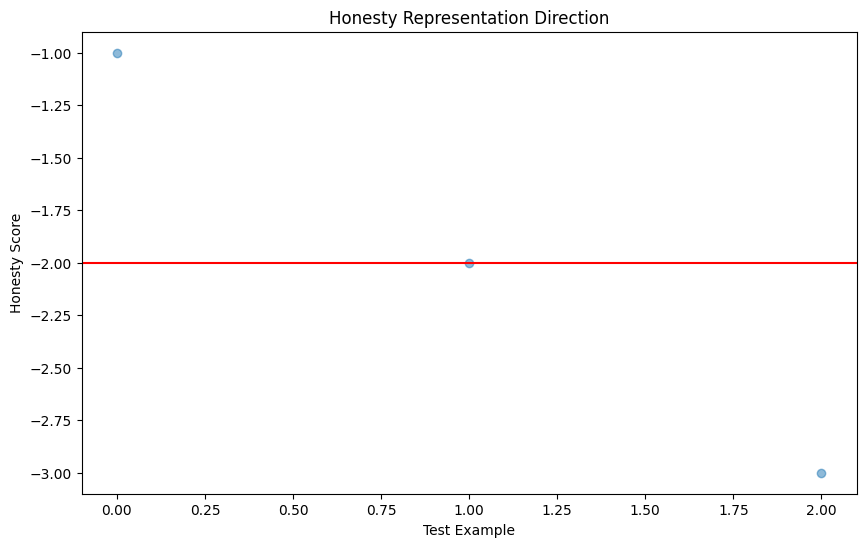

In [ ]:
# Set up plotting
results = {layer: {} for layer in hidden_layers}
rep_readers_means = {}
rep_readers_means['honesty'] = {layer: 0 for layer in hidden_layers}

# For LatentScan
honest_label = 0
true_label = 0
latent_scan_label_descriptions = {
    (honest_label, true_label): "Honest and True",
    (honest_label, 1 - true_label): "Honest and False",
    (1 - honest_label, true_label): "Dishonest and True",
    (1 - honest_label, 1 - true_label): "Dishonest and False"
}

def flat(H):
    return [h[0] if isinstance(h, np.ndarray) else (h.item() if hasattr(h, 'item') else h) for h in H]

# Calculate results
for layer in hidden_layers:
    results[layer]["honesty"] = flat(H_tests[layer])
    rep_readers_means['honesty'][layer] = np.mean(results[layer]["honesty"])

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(range(len(results[hidden_layers[0]]["honesty"])), results[hidden_layers[0]]["honesty"], alpha=0.5)
plt.axhline(y=rep_readers_means['honesty'][hidden_layers[0]], color='r', linestyle='-')
plt.title("Honesty Representation Direction")
plt.xlabel("Test Example")
plt.ylabel("Honesty Score")
plt.show()